In [71]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [73]:
import sys
sys.path.append("/bayesgpt")

In [74]:
import numpy as np

In [75]:
from simulators.model_family import NestedModelFamily
from simulators.benchmarks.ddms.ddm import DDM
from simulators.benchmarks.ddms.ddm_priors import ddm_baseline_priors

In [76]:
import bayesflow as bf

In [109]:
class DDMModelFamilyBF:

    def __init__(self):
        self.model_family = NestedModelFamily(
            model=DDM(),
            prior_fun=ddm_baseline_priors(),
            mask_randomizer_kwargs=dict(
                free_intrinsics=["v", "a", "tau", "s_v", "s_tau"],
                fixed_intrinsics=[],
                fixed_values={}
            )
    )

    def sample(self, batch_size, num_obs=500, flatten_param_outputs=False, **kwargs):

        if isinstance(batch_size, tuple):
             batch_size = batch_size[0]

        sample_kwargs = {
            "max_num_regressors": 0,
            "max_num_categories": 0
        }

        samples = self.model_family.batch_sample(
            batch_size=batch_size,
            num_obs=num_obs,
            flatten_param_outputs=flatten_param_outputs,
            **sample_kwargs,
            **kwargs
        )

        rts = samples["sim_data"]["rts"]
        choices = samples["sim_data"]["choices"]
        params = samples["param_matrices"].squeeze(axis=1)

        return {"rts": rts, "choices": choices, "params": params}

In [96]:
model_family = DDMModelFamilyBF()

In [97]:
ddm_samples = model_family.sample(4, num_obs=500)
for k, v in ddm_samples.items():
    print(k, v.shape if isinstance(v, np.ndarray) else (v.keys() if isinstance(v, dict) else v))

rts (4, 500, 1)
choices (4, 500, 1)
params (4, 5)


In [98]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate(["rts", "choices"], into="summary_variables")
    .rename("params", "inference_variables")
)

In [99]:
adapted = adapter(model_family.sample(4))

In [100]:
for k, v in adapted.items():
    print(k, v.shape)

summary_variables (4, 500, 2)
inference_variables (4, 5)


In [101]:
summary_net = bf.networks.SetTransformer()
inference_net = bf.networks.FlowMatching()

In [102]:
workflow = bf.BasicWorkflow(
    simulator=model_family,
    adapter=adapter,
    inference_network=inference_net,
    summary_network=summary_net,
    checkpoint_filepath=f"../checkpoints/model_family_bf_intercept_only"
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


In [110]:
history = workflow.fit_online(
    epochs=10,
    steps_per_epoch=10,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - loss: 1.8750
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - loss: 1.8478
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 1.8837
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - loss: 1.8268
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 1.8917
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - loss: 1.8078
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 1.8287
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - loss: 1.9503
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - loss: 1.7458
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 1.9208


INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '../checkpoints/model_family_bf_intercept_only/model.model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


In [104]:
param_names = [r"$v$", r"$a$", r"$\tau$", r"$s_v$", r"$s_\tau$"]

In [105]:
val_sims = workflow.simulate(300)
val_samples = workflow.sample(num_samples=300, conditions=val_sims)

In [106]:
for k, v in val_samples.items():
    print(k, v.shape)

params (300, 300, 5)


In [107]:
for k, v in val_sims.items():
    print(k, v.shape)

rts (300, 500, 1)
choices (300, 500, 1)
params (300, 5)


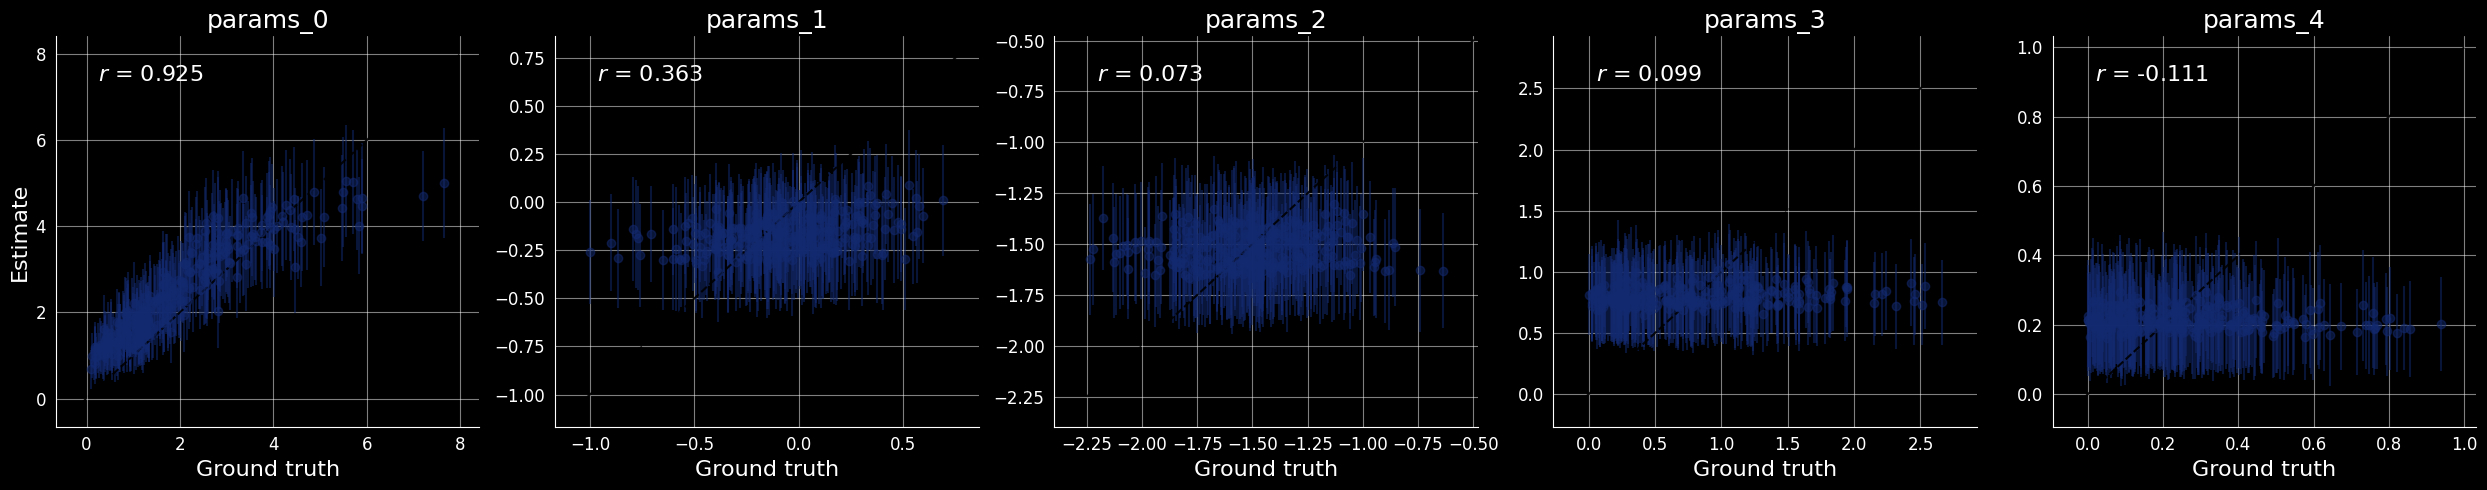

In [108]:
f = bf.diagnostics.recovery(val_samples, val_sims)